In [1]:
import numpy as np 
import matplotlib.pyplot as plt 


In [2]:
data_ini=np.loadtxt("class_public/output/reiotest_pk.dat",comments="#")
data_fin=np.loadtxt("class_public/output/reiotest_1_pk.dat",comments="#")


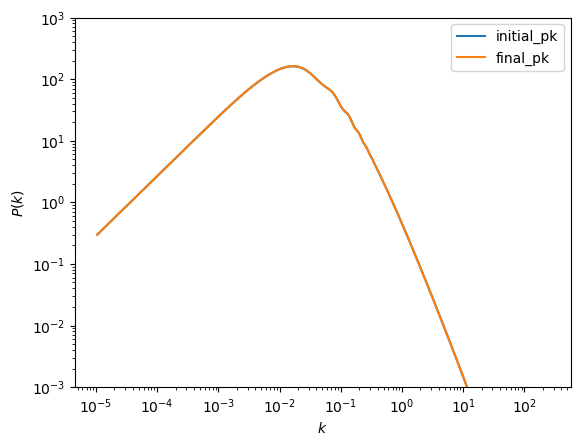

In [3]:
plt.loglog(data_ini[:,0],data_ini[:,1],label="initial_pk")
plt.loglog(data_fin[:,0],data_fin[:,1],label='final_pk')
plt.legend()
plt.ylabel(r'$P(k)$')
plt.xlabel(r'$k$')
plt.ylim([0.001,1e3])
plt.show()

In [4]:
cl_fin=np.loadtxt("class_public/output/reiotest_1_cl.dat",comments="#")
cl_default=np.loadtxt('class_public/output/reio_default_cl.dat',comments='#')


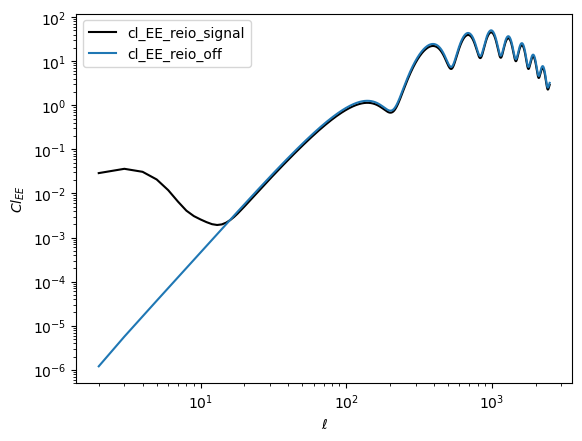

In [14]:
plt.loglog(cl_fin[:,0],cl_fin[:,2],label='cl_EE_reio_signal',color='black')
plt.loglog(cl_default[:,0],cl_default[:,2],label='cl_EE_reio_off')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$Cl_{EE}$')
plt.legend()
plt.show()

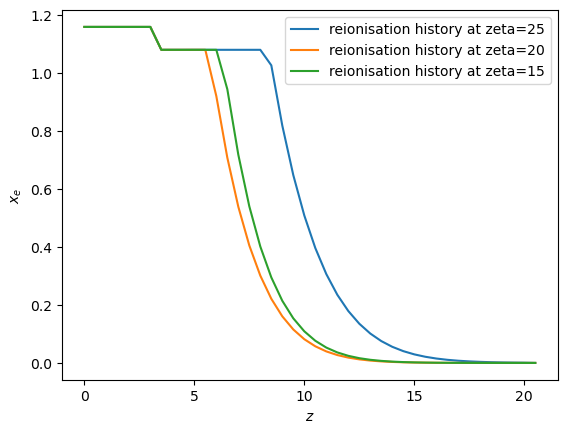

In [15]:
reio_hist=np.loadtxt('xe_history_full.dat',comments='#')
reio_hist_old=np.loadtxt('xe_history_full_1.dat',comments='#')
reio_hist_2=np.loadtxt('xe_history_full_2.dat',comments='#')

plt.plot(reio_hist[:,0],reio_hist[:,1],label='reionisation history at zeta=25')
plt.plot(reio_hist_old[:,0],reio_hist_old[:,1],label='reionisation history at zeta=20')
plt.plot(reio_hist_2[:,0],reio_hist_2[:,1],label='reionisation history at zeta=15')

plt.xlabel(r'$z$')
plt.ylabel(r'$x_e$')
plt.legend()
plt.show()


In [4]:
chain=np.load("mcmc_chain.npy")

In [6]:
chain[0]

array([[10.40771212,  8.69914151],
       [12.32705362,  9.08275861],
       [13.26064263,  8.92265239],
       [10.10186155,  8.98486958],
       [15.18052852,  9.18943341],
       [17.0774344 ,  9.10020609],
       [12.56921883,  9.03850861],
       [15.85816192,  8.87404082]])

raw chain shape (nsteps, nwalkers, ndim): (40, 8, 2)
flattened samples shape (Nsamples, ndim): (240, 2)
Removed no burn in
\zeta = 13.9^{+4.4}_{-3.8}
\log_{10} M_{\min} = 8.97\pm 0.36


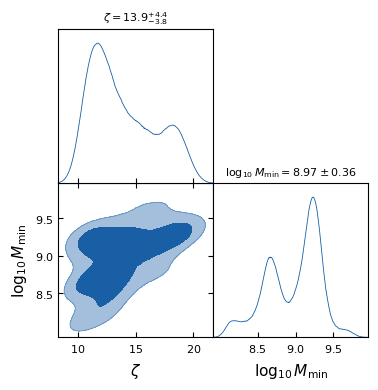

saved -> posterior_triangle.png


In [ ]:
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

CHAIN_FILE = "mcmc_chain.npy"
N_BURN     = 10          
chain = np.load(CHAIN_FILE)
print("raw chain shape (nsteps, nwalkers, ndim):", chain.shape)




names  = ["zeta", "log10_Mmin"]
labels = [r"\zeta", r"\log_{10} M_{\min}"]

samples = MCSamples(samples=flat, names=names, labels=labels,
                    label="tau-constrained posterior")

# optional: print 1D marginalized constraints (median +/- 68%)
print(samples.getInlineLatex("zeta", limit=1))
print(samples.getInlineLatex("log10_Mmin", limit=1))

# triangle plot
g = plots.get_subplot_plotter()
g.triangle_plot(samples,
                filled=True,
                contour_colors=["#185FA5"],
                title_limit=1)          # show 68% limit in the 1D panel titles


plt.show()                             

after dropping 50 burn-in: 1302 samples
Removed no burn in


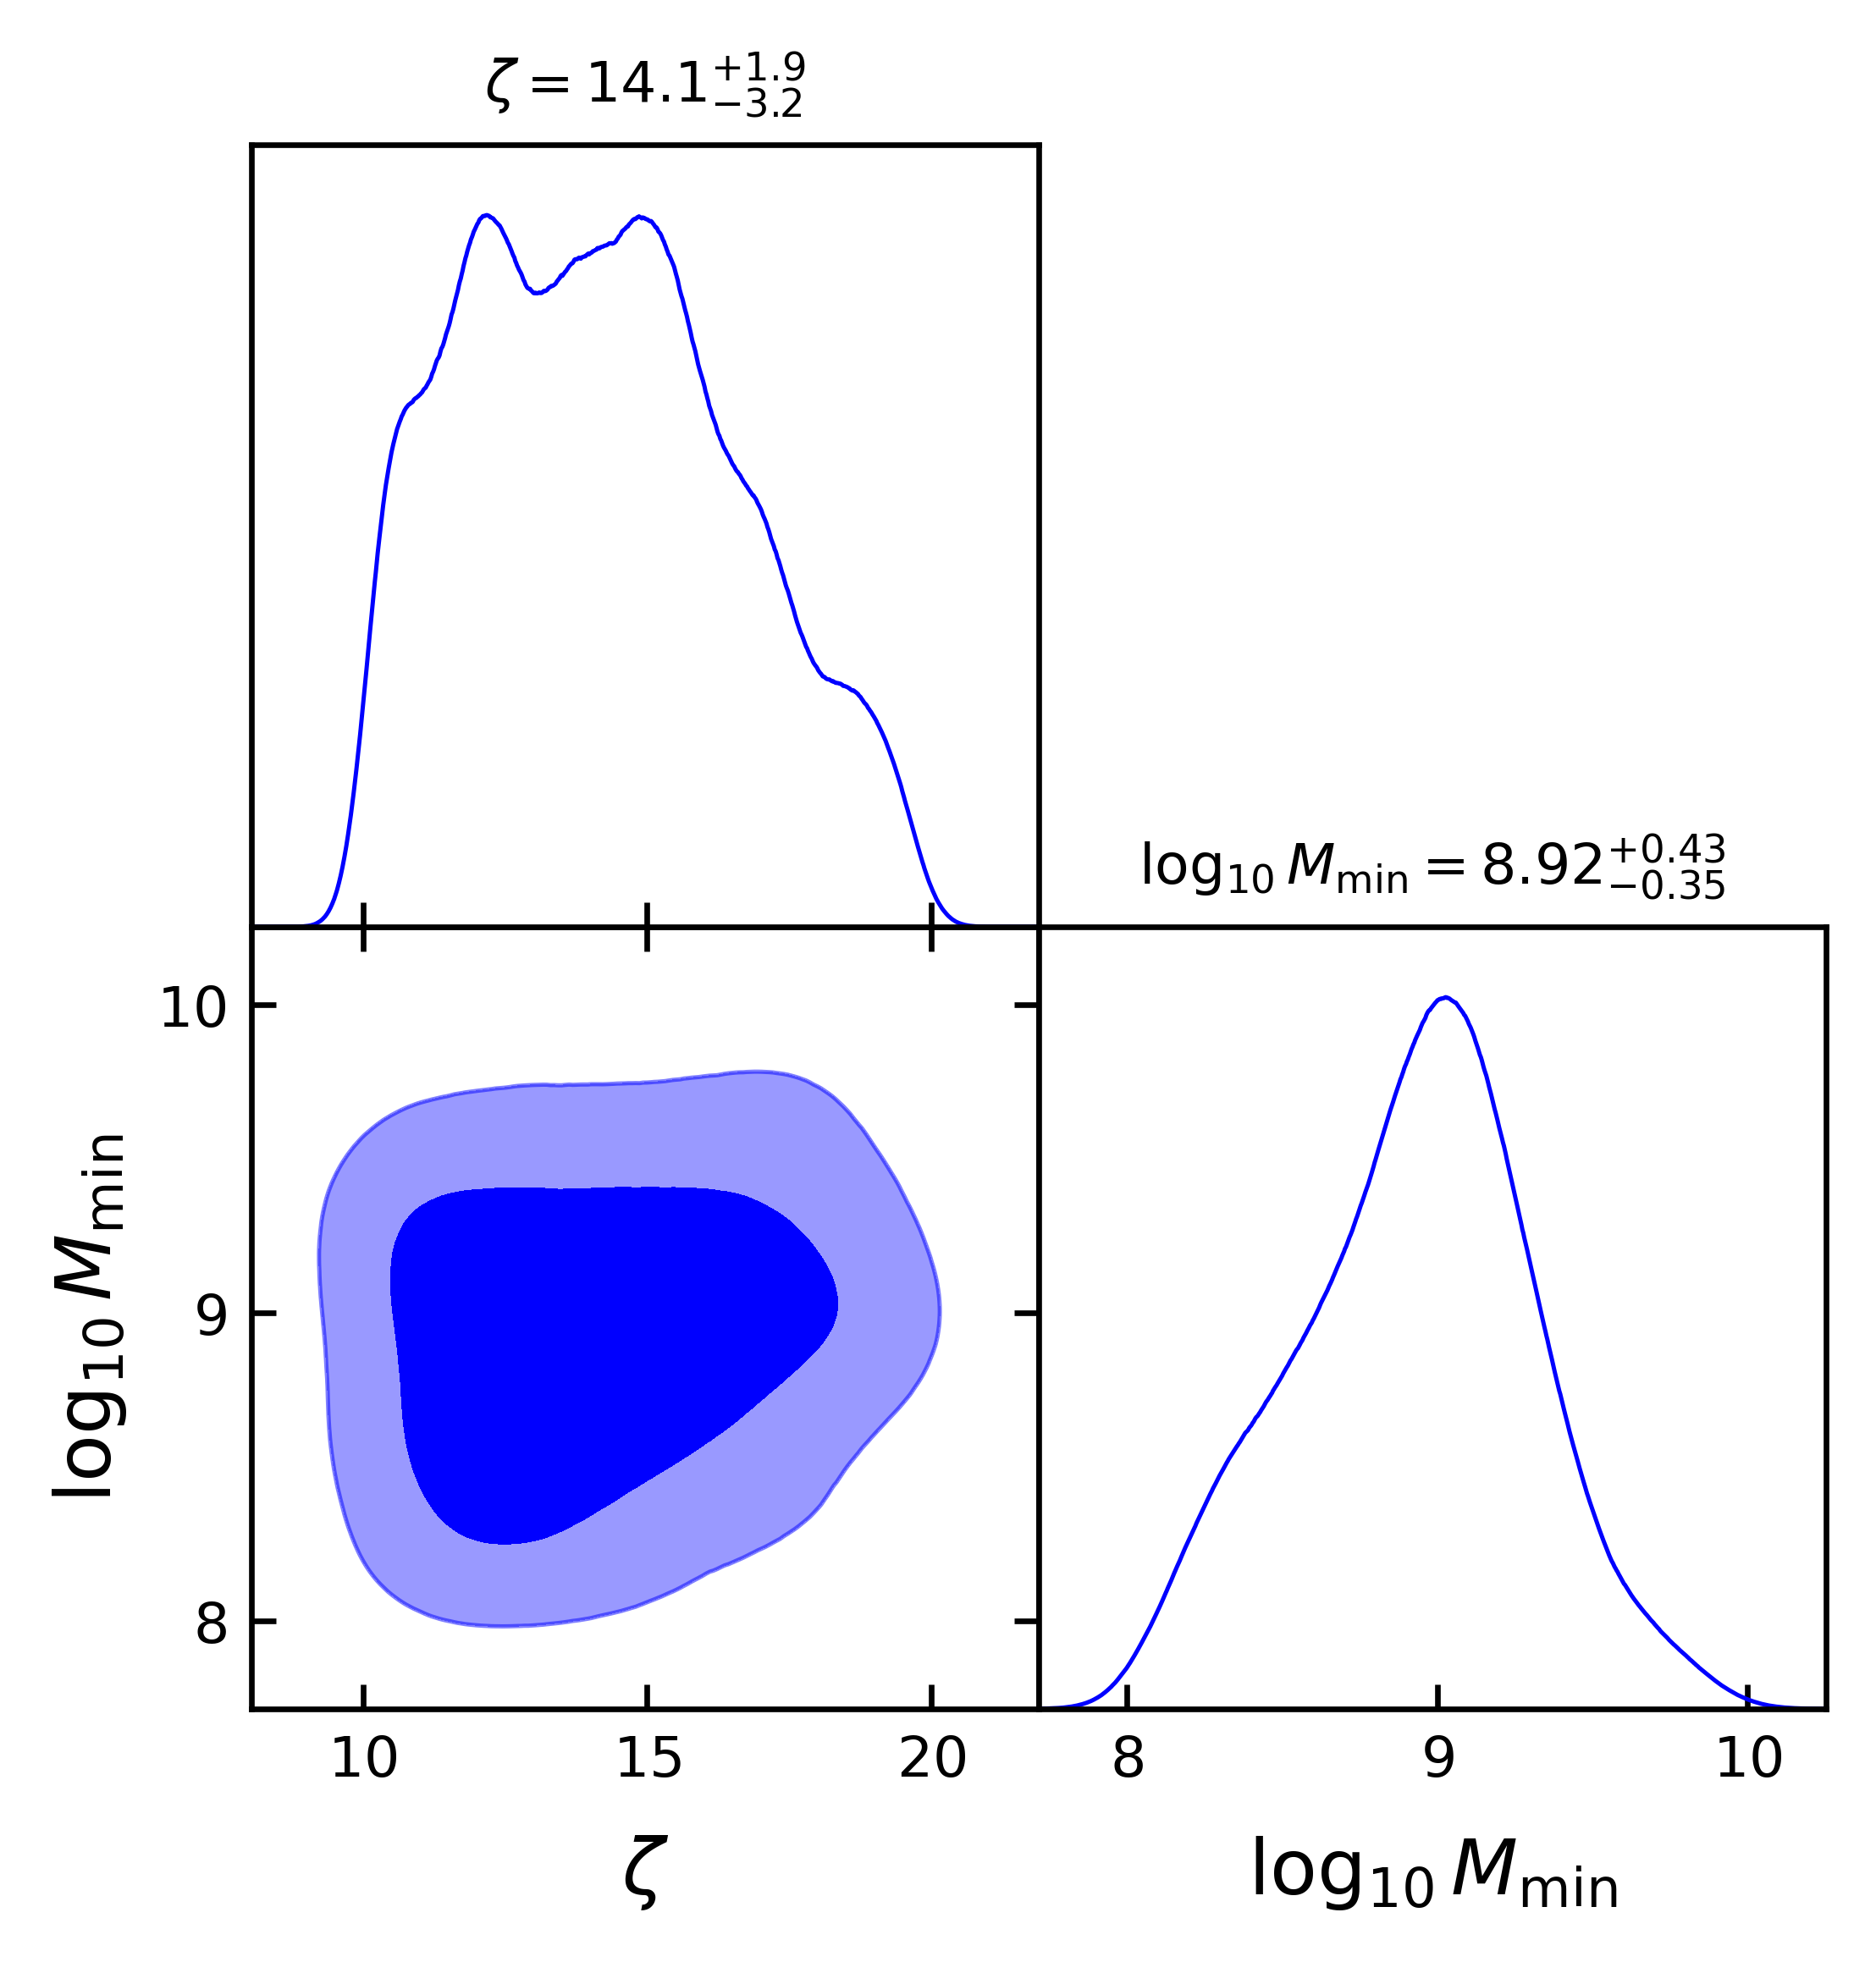

In [13]:
import re
import numpy as np
from getdist import MCSamples, plots
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['figure.dpi']=600

LOG_FILE = "mcmc.log"
N_BURN   = 50
_num = r"([-+]?\d+\.?\d*(?:[eE][-+]?\d+)?)"
pat = re.compile(
    r"zeta\s*=\s*"        + _num +
    r".*?log10_Mmin\s*=\s*" + _num +
    r".*?tau\s*=\s*"      + _num +
    r".*?logL\s*=\s*"     + _num
)

zeta, lmmin, tau, logL = [], [], [], []
with open(LOG_FILE) as f:
    for line in f:
        m = pat.search(line)
        if m:
            zeta.append(float(m.group(1)))
            lmmin.append(float(m.group(2)))
            tau.append(float(m.group(3)))
            logL.append(float(m.group(4)))

zeta  = np.array(zeta)
lmmin = np.array(lmmin)


if N_BURN > 0 and len(zeta) > N_BURN:
    zeta, lmmin = zeta[N_BURN:], lmmin[N_BURN:]
    print(f"after dropping {N_BURN} burn-in: {len(zeta)} samples")

flat = np.column_stack([zeta, lmmin])

names  = ["zeta", "log10_Mmin"]
labels = [r"\zeta", r"\log_{10} M_{\min}"]

samples = MCSamples(samples=flat, names=names, labels=labels, label="tau-constrained posterior")



# triangle plot
g = plots.get_subplot_plotter()
g.triangle_plot(samples, filled=True, contour_colors=['blue'], title_limit=1)
plt.show()

In [3]:
import numpy as np

chain=np.loadtxt("tau_mcmc.1.txt",comments='#')
best_index = np.argmin(chain[:,1])
print(best_index)
best_fit_params = [chain[best_index,2],chain[best_index,3]]

print("Best-fit parameters:", best_fit_params)


418
Best-fit parameters: [np.float64(8.7800638), np.float64(8.30398)]


In [2]:
import numpy as np
chain = np.loadtxt("tau_mcmc.1.txt", comments="#")
i = np.argmin(chain[:, 1])     
print("zeta       =", chain[i, 2])
print("log10_Mmin =", chain[i, 3])
print("tau=",chain[i,4])
print("chi2       =", chain[i, 7])

 

zeta       = 8.7800638
log10_Mmin = 8.30398
tau= 4.5849675
chi2       = 1.8765247e-08


In [30]:
import numpy as np
chain = np.loadtxt("chains/classy_planck_TTEE.1.txt", comments="#")
i = np.argmin(chain[:, 9])     
print("zeta       =", chain[i, 2])
print("log10_Mmin =", chain[i, 3])
print("tau=",chain[i,4])
print("chi2       =", chain[i, 7])


zeta       = 6.7046912
log10_Mmin = 7.9722438
tau= 0.053811841
chi2       = 4.9416424


In [29]:
chain

array([[  1.      , 214.57626 ,  13.963709, ..., 419.26925 , 395.67861 ,
         23.590636],
       [  1.      , 214.55706 ,  13.953891, ..., 419.23083 , 395.76393 ,
         23.466902],
       [  1.      , 214.53931 ,  13.933296, ..., 419.19533 , 395.70148 ,
         23.493847],
       ...,
       [  2.      , 215.1502  ,  33.390649, ..., 420.41712 , 395.95927 ,
         24.457851],
       [  3.      , 214.58183 ,  33.206213, ..., 419.28037 , 395.80525 ,
         23.47512 ],
       [  6.      , 214.61077 ,  36.75119 , ..., 419.33826 , 395.78163 ,
         23.55663 ]], shape=(3040, 12))

In [1]:
import numpy as np
chain = np.loadtxt("chains/classy_planck_TTEE.1.txt", comments="#")
chain_sorted=chain[np.argsort(chain[:,1])[:201]]
chain_sorted
# weights = chain_sorted[:, 0]
# probs = weights / weights.sum()
# idx = np.random.choice(len(chain_sorted), size=200, replace=False, p=probs)
# sample200 = chain[idx]
sample200=chain_sorted

In [2]:
zeta=sample200[:,2]
log10mmin=sample200[:,3]

In [3]:
import run_pipeline as P
import numpy as np
res=[]
for i,j in zip(zeta,log10mmin):
    res.append(P.reionization_history(i,j))


In [3]:
res[0]

[(5.0, 1.0000462532043457, 1.0789499025821685),
 (5.400000095367432, 0.8908787965774536, 0.9611691336274146),
 (5.800000190734863, 0.7720301151275635, 0.8329432912111282),
 (6.199999809265137, 0.6660833954811096, 0.7186373753845692),
 (6.599999904632568, 0.5720974206924438, 0.6172359071850777),
 (7.0, 0.48913514614105225, 0.5277279091715813),
 (7.400000095367432, 0.4162737727165222, 0.44911777338385583),
 (7.800000190734863, 0.3526182174682617, 0.3804397948265076),
 (8.199999809265137, 0.29729562997817993, 0.32075225518345835),
 (8.600000381469727, 0.24946826696395874, 0.2691513132274151),
 (9.0, 0.20834000408649445, 0.22477803040891886),
 (9.399999618530273, 0.17315927147865295, 0.18682153799831866),
 (9.800000190734863, 0.14322614669799805, 0.1545266896724701),
 (10.199999809265137, 0.11789482831954956, 0.12719673027396203),
 (10.600000381469727, 0.09657175093889236, 0.10419126208797097),
 (11.0, 0.07871849834918976, 0.08492938786894083),
 (11.399999618530273, 0.06385074555873871, 0.

In [2]:
print(len(res))
pick=200
res_picked=res[:pick]
len(res_picked)

201


200

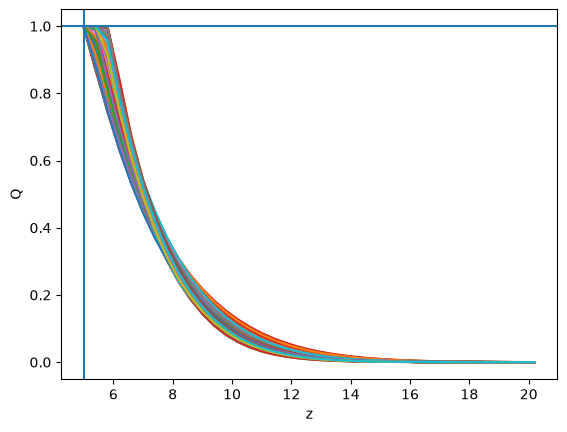

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

for hist in res_picked:
    z, Q, xe = zip(*hist)
    ax.plot(z, Q)

ax.set_xlabel("z")
ax.set_ylabel("Q")
# ax.set_ylim([0.9,1])
ax.axvline(5)
ax.axhline(1)
plt.show()

In [4]:
chisq_ttee=sample200[:,9]

NameError: name 'sample200' is not defined

NameError: name 'chisq_ttee' is not defined

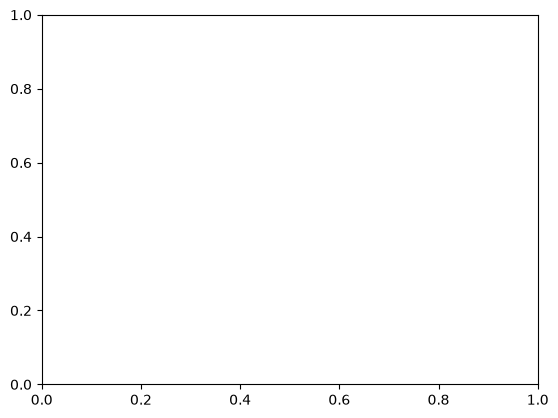

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

fig, ax = plt.subplots()

norm = mpl.colors.Normalize(vmin=np.min(chisq_ttee), vmax=np.max(chisq_ttee))
cmap = mpl.cm.jet

z_min,Q_min,xe_min=zip(*res[0])


for hist, c in zip(res_picked, chisq_ttee):
    z, Q, xe = zip(*hist)
    if Q[0] < 0.99:
        print('Error!', Q[0])
    ax.plot(z, Q, color=cmap(norm(c)),lw=0.3)
ax.plot(z_min,Q_min,color="black",label='best_fit')


ax.set_xlabel("z")
ax.set_ylabel("Q")
# ax.set_ylim([0.9, 1])
ax.axvline(5)
ax.axhline(1)

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label=r"$\chi^2$")
plt.savefig("plot_Q_z_hue_cl.png", dpi=600)
plt.legend()
plt.show()

TypeError: get_class_cl() missing 1 required positional argument: 'CLASS_DIR'

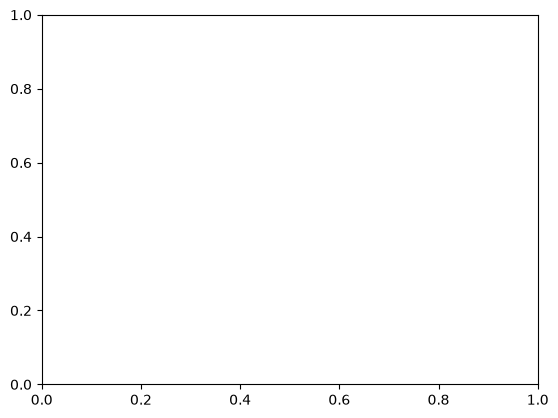

In [10]:
import run_pipeline as P
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from pathlib import Path



fig, ax = plt.subplots()

norm = mpl.colors.Normalize(vmin=np.min(chisq_ttee), vmax=np.max(chisq_ttee))
cmap = mpl.cm.jet

for hist, c in zip(res_picked, chisq_ttee):
    z, Q, xe = zip(*hist)
    if Q[0] < 0.99:
        print('Error!', Q[0])
    ell, cl_tt, cl_ee, cl_te, cl_bb=P.get_class_cl(z,xe)
    plt.plot(ell,cl_tt,color=cmap(norm(c)),lw=0.3)


ax.set_xlabel("l")
ax.set_ylabel("Cl")

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label=r"$\chi^2$")
plt.savefig("plot_Q_z_hue_cls.png", dpi=600)
plt.legend()
plt.show()


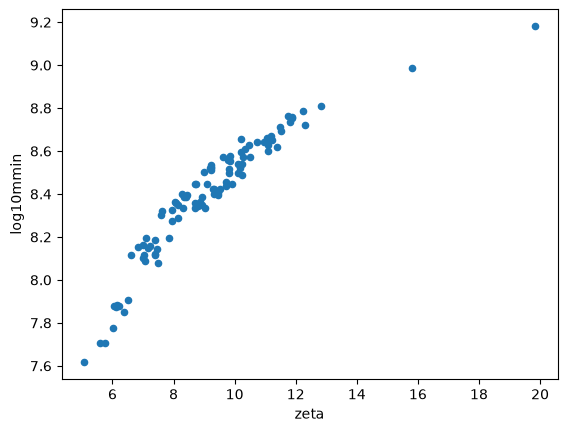

In [66]:
plt.scatter(zeta[:pick],log10mmin[:pick],s=20)
plt.xlabel('zeta')
plt.ylabel('log10mmin')
plt.show()

In [7]:
import numpy as np
chain = np.loadtxt("chains/tau_mcmc.1.txt", comments="#")
chain_sorted=chain[np.argsort(chain[:,1])[:201]]
chain_sorted
# weights = chain_sorted[:, 0]
# probs = weights / weights.sum()
# idx = np.random.choice(len(chain_sorted), size=200, replace=False, p=probs)
# sample200 = chain[idx]
sample200_tau=chain_sorted

In [8]:
zeta_tau=sample200_tau[:,2]
log10mmin_tau=sample200_tau[:,3]

In [4]:
import run_pipeline as P
import numpy as np
res_tau=[]
for i,j in zip(zeta_tau,log10mmin_tau):
    res_tau.append(P.reionization_history(i,j))


In [ ]:
print(len(res_tau))
pick=100
res_picked_tau=res_tau[:200]
len(res_picked_tau)


201


200

In [10]:
chisq=sample200_tau[:200,7]

In [19]:
z_min,Q_min,xe_min=zip(*res_tau[0])

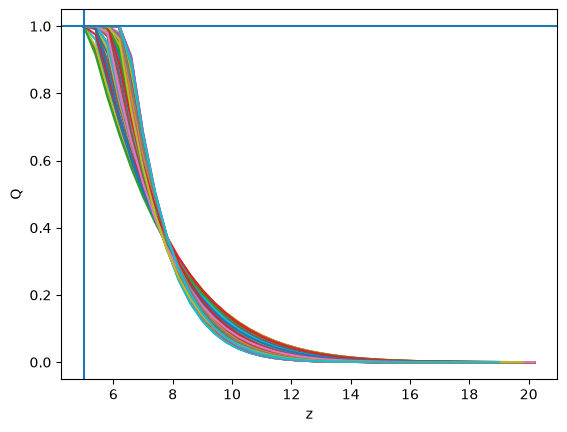

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

for hist in res_picked_tau:
    z, Q, xe = zip(*hist)
    # print(Q[0])
    if(Q[0]<0.99):
        print('Error!')
    ax.plot(z, Q)

ax.set_xlabel("z")
ax.set_ylabel("Q")
# ax.set_ylim([0.9,1])
ax.axvline(5)
ax.axhline(1)
plt.savefig("plot_Q_z.png",dpi=600)
plt.show()

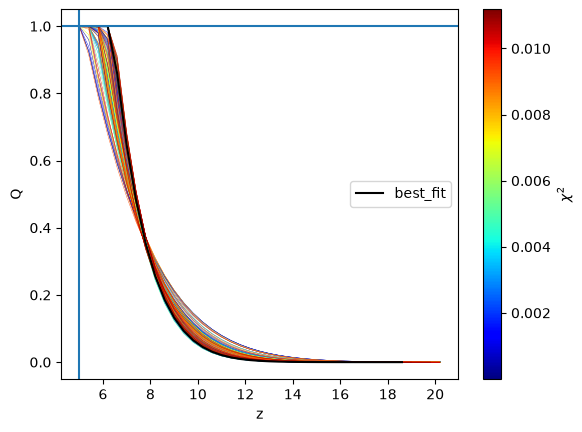

In [25]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

fig, ax = plt.subplots()

norm = mpl.colors.Normalize(vmin=np.min(chisq), vmax=np.max(chisq))
cmap = mpl.cm.jet

for hist, c in zip(res_picked_tau, chisq):
    z, Q, xe = zip(*hist)
    if Q[0] < 0.99:
        print('Error!', Q[0])
    ax.plot(z, Q, color=cmap(norm(c)),lw=0.3)
ax.plot(z_min,Q_min,color="black",label='best_fit')


ax.set_xlabel("z")
ax.set_ylabel("Q")
# ax.set_ylim([0.9, 1])
ax.axvline(5)
ax.axhline(1)

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label=r"$\chi^2$")
plt.savefig("plot_Q_z_hue.png", dpi=600)
plt.legend()
plt.show()

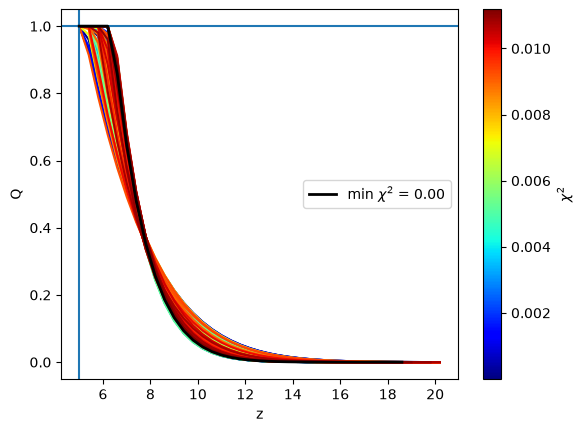

In [26]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

fig, ax = plt.subplots()

norm = mpl.colors.Normalize(vmin=np.min(chisq), vmax=np.max(chisq))
cmap = mpl.cm.jet

min_idx = np.argmin(chisq)

for i, (hist, c) in enumerate(zip(res_picked_tau, chisq)):
    z, Q, xe = zip(*hist)
    if Q[0] < 0.99:
        print('Error!', Q[0])
    if i == min_idx:
        continue  # skip here, plot it last so it sits on top
    ax.plot(z, Q, color=cmap(norm(c)), zorder=1)

# plot the minimum-chi-square curve on top
z, Q, xe = zip(*res_picked_tau[min_idx])
ax.plot(z, Q, color='black', lw=2, zorder=5,
        label=fr"min $\chi^2$ = {chisq[min_idx]:.2f}")

ax.set_xlabel("z")
ax.set_ylabel("Q")
ax.axvline(5)
ax.axhline(1)
ax.legend()

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label=r"$\chi^2$")
plt.savefig("plot_Q_z_hue.png", dpi=600)
plt.show()

In [1]:
import numpy as np

In [9]:
zeta_tau[np.random.randint(0,100,20)]

array([47.76337  , 43.820093 , 46.230887 , 33.188868 , 43.820093 ,
       13.723815 , 40.07144  , 30.366039 , 32.241026 , 14.901527 ,
       48.740521 , 40.07144  , 13.81979  , 22.358543 , 36.12207  ,
        7.0731656, 23.466941 , 38.573612 , 15.040945 , 38.573612 ])

In [11]:
from getdist import loadMCSamples

In [25]:
samples=loadMCSamples("chains/classy_planck_TTEE",settings={"ignore_rows":0.4})
len(samples.samples)

chains/classy_planck_TTEE.1.txt
Removed 0.4 as burn in


1824

In [26]:
samples=loadMCSamples("chains/classy_planck_TTEE")
len(samples.samples)


chains/classy_planck_TTEE.1.txt
Removed no burn in


3040

In [35]:
samples.samples[:,4]

array([419.26925, 419.23083, 419.19533, ..., 420.41712, 419.28037,
       419.33826], shape=(3040,))

In [19]:
samples.ignore_frac

0.0

In [31]:
samples.samples.shape

(3040, 8)

In [1]:
from classy import Class
c = Class(); c.set({"output":"mPk","P_k_max_1/Mpc":50.,"z_max_pk":1.,"H0":67.36,"omega_b":0.02237,"omega_cdm":0.12,"n_s":0.9649,"A_s":2.1e-9}); c.compute()
pk, k, z = c.get_pk_and_k_and_z(nonlinear=False)
print("z_grid:", z)
print("P[:,0] vs P[:,-1] (larger = z=0):", pk[0,0], pk[0,-1])

z_grid: [2.00000000e+00 1.71951122e+00 1.46480350e+00 1.23344158e+00
 1.02322012e+00 8.32147157e-01 6.58430135e-01 5.00463426e-01
 3.56815735e-01 2.26215504e-01 1.65922457e-01 1.08515241e-01
 5.38614012e-02 1.83490374e-03 0.00000000e+00]
P[:,0] vs P[:,-1] (larger = z=0): 27.389144213536913 157.49206941069568


In [2]:
print("k range:", k.min(), "to", k.max(), "1/Mpc")
print("number of k points:", len(k))

k range: 7.054894542137852e-06 to 56.0967758186827 1/Mpc
number of k points: 131


In [20]:
from classy import Class
import numpy as np
c=Class(); c.set({"output":"mPk","P_k_max_1/Mpc":500.,"z_max_pk":1.,"k_per_decade_for_pk":20,
                  "H0":67.36,"omega_b":0.02237,"omega_cdm":0.12,"n_s":0.9649,"A_s":2.1e-9}); c.compute()
pk,k,z = c.get_pk_and_k_and_z(nonlinear=False)
print("k range:", k.min(), "to", k.max(), "1/Mpc,  points:", len(k))
h=0.6736; Pk0=pk[:,-1]
lnk=np.log(k/h); lnpk=np.log(Pk0*h**3)
import os,sys; os.chdir("/home/aayush/PROJECT_NCRA/data_files"); sys.path.insert(0,"/home/aayush/PROJECT_NCRA")
import reion_uvlf_4params as uvlf
logl, d = uvlf.log_likelihood(-0.458, -0.883, 10.78, 1.148, lnk, lnpk,
                              0.31, 0.69, h, 0.049, YHe=0.24)
print("chi2:", -2*logl, " tau_e:", d["tau_e"])

k range: 7.054894542137852e-06 to 506.93193539144147 1/Mpc,  points: 209
chi2: 12543.362427974447  tau_e: 0.06663963046243535


In [23]:
for pkmax, kperdec in [(50, None), (100, 10), (500, 20), (1000, 30), (2000, 40)]:
    settings = {"output":"mPk","z_max_pk":1.,"P_k_max_1/Mpc":pkmax,
                "H0":67.36,"omega_b":0.02237,"omega_cdm":0.12,"n_s":0.9649,"A_s":2.1e-9}
    if kperdec: settings["k_per_decade_for_pk"] = kperdec
    c = Class(); c.set(settings); c.compute()
    print(f"P_k_max={pkmax}, kperdec={kperdec}: CLASS sigma8 = {c.sigma8():.5f}")
    c.struct_cleanup()
    pk,k,z = c.get_pk_and_k_and_z(nonlinear=False)
    h=0.6736; Pk0=pk[:,-1]; kk=k/h; Pk=Pk0*h**3
    R=8.0; x=kk*R; W=3*(np.sin(x)-x*np.cos(x))/x**3
    s8 = np.sqrt(np.trapezoid(Pk*W**2*kk**2, kk)/(2*np.pi**2))
    print(f"    your sigma8 from lnk/lnpk = {s8:.5f}")

P_k_max=50, kperdec=None: CLASS sigma8 = 0.82291
    your sigma8 from lnk/lnpk = 0.82289
P_k_max=100, kperdec=10: CLASS sigma8 = 0.82291
    your sigma8 from lnk/lnpk = 0.82289
P_k_max=500, kperdec=20: CLASS sigma8 = 0.82291
    your sigma8 from lnk/lnpk = 0.82302
P_k_max=1000, kperdec=30: CLASS sigma8 = 0.82291
    your sigma8 from lnk/lnpk = 0.82301
P_k_max=2000, kperdec=40: CLASS sigma8 = 0.82291
    your sigma8 from lnk/lnpk = 0.82300


In [24]:
import massfunction
for pkmax, kpd in [(50,None),(500,20),(2000,40)]:
    s={"output":"mPk","z_max_pk":1.,"P_k_max_1/Mpc":pkmax,"H0":67.36,"omega_b":0.02237,"omega_cdm":0.12,"n_s":0.9649,"A_s":2.1e-9}
    if kpd: s["k_per_decade_for_pk"]=kpd
    c=Class(); c.set(s); c.compute()
    pk,k,z=c.get_pk_and_k_and_z(nonlinear=False); h=0.6736
    lnk=np.log(k/h); lnpk=np.log(pk[:,-1]*h**3)
    cdict={"omega_M_0":0.314,"omega_b_0":0.049,"h":h,"YHe":0.24,"omega_L_0":0.686}
    M,_,_,_,_,_,dndm,_ = massfunction.get_massfunction(8.0, 12.0, 0.1, 6.0, lnk, lnpk, cdict, fit="ST", delta_c=1.686)
    # dndm at a small mass (say M=10^8) and large (10^11)
    print(f"pkmax={pkmax}: dndm[0]={dndm[0]:.3e}, dndm[-1]={dndm[-1]:.3e}")
    c.struct_cleanup()
    

pkmax=50: dndm[0]=1.429e-07, dndm[-1]=1.146e-15
pkmax=500: dndm[0]=1.636e-07, dndm[-1]=5.819e-16
pkmax=2000: dndm[0]=1.738e-07, dndm[-1]=1.787e-16


In [6]:
from classy import Class
import numpy as np
c=Class(); c.set({"output":"mPk","P_k_max_1/Mpc":500.,"z_max_pk":1.,"k_per_decade_for_pk":20,
                  "H0":67.36,"omega_b":0.02237,"omega_cdm":0.12,"n_s":0.9649,"A_s":2.1e-9}); c.compute()
print("CLASS sigma8:", c.sigma8())     # should be ~0.81

# now compute sigma8 from YOUR lnk/lnpk the way the model does, and compare
pk,k,z = c.get_pk_and_k_and_z(nonlinear=False)
h=0.6736; Pk0=pk[:,-1]
lnk=np.log(k/h); lnpk=np.log(Pk0*h**3)

# manually compute sigma(R=8 Mpc/h) from your lnk, lnpk
kk = np.exp(lnk)       # h/Mpc
Pk = np.exp(lnpk)      # (Mpc/h)^3
R = 8.0                # Mpc/h
x = kk*R
W = 3*(np.sin(x) - x*np.cos(x))/x**3
integrand = Pk * W**2 * kk**2
sigma8_sq = np.trapezoid(integrand, kk) / (2*np.pi**2)
print("sigma8 from your lnk/lnpk:", np.sqrt(sigma8_sq))

CLASS sigma8: 0.8229100217873316
sigma8 from your lnk/lnpk: 0.823024942854589


In [25]:
for pkmax, kpd in [(500,20),(1000,30),(2000,40),(5000,60),(10000,80)]:
    # ... compute dndm[-1] ...
    print(f"pkmax={pkmax}, kpd={kpd}: dndm[-1]={dndm[-1]:.3e}")

pkmax=500, kpd=20: dndm[-1]=1.787e-16
pkmax=1000, kpd=30: dndm[-1]=1.787e-16
pkmax=2000, kpd=40: dndm[-1]=1.787e-16
pkmax=5000, kpd=60: dndm[-1]=1.787e-16
pkmax=10000, kpd=80: dndm[-1]=1.787e-16


In [26]:
from classy import Class
import numpy as np, os, sys
os.chdir("/home/aayush/PROJECT_NCRA/data_files"); sys.path.insert(0,"/home/aayush/PROJECT_NCRA")
import reion_uvlf_4params as uvlf
c=Class(); c.set({"output":"mPk","P_k_max_1/Mpc":500.,"z_max_pk":1.,"k_per_decade_for_pk":20,"H0":67.36,"omega_b":0.02237,"omega_cdm":0.12,"n_s":0.9649,"A_s":2.1e-9}); c.compute()
h=0.6736

# METHOD 1: your current non-uniform CLASS grid
pk,k,z = c.get_pk_and_k_and_z(nonlinear=False)
lnk1=np.log(k/h); lnpk1=np.log(pk[:,-1]*h**3)
logl1,d1 = uvlf.log_likelihood(-0.458,-0.883,10.78,1.148, lnk1,lnpk1, 0.314,0.686, h,0.049, YHe=0.24)
print("NON-uniform grid chi2:", -2*logl1)

# METHOD 2: uniform logspace grid (what sigma expects)
kk=np.logspace(np.log10(k.min()), np.log10(k.max()), 2000)   # uniform in log-k
Pk0=np.array([c.pk_lin(kv, 0.0) for kv in kk])
lnk2=np.log(kk/h); lnpk2=np.log(Pk0*h**3)
logl2,d2 = uvlf.log_likelihood(-0.458,-0.883,10.78,1.148, lnk2,lnpk2, 0.314,0.686, h,0.049, YHe=0.24)
print("UNIFORM grid chi2:", -2*logl2)

NON-uniform grid chi2: 12235.98155698664
UNIFORM grid chi2: 55.125653812700456


In [11]:
from classy import Class
import numpy as np
import os, sys

c = Class()
c.set({"output":"mPk", "P_k_max_1/Mpc":500., "z_max_pk":1., "k_per_decade_for_pk":20,
       "H0":67.36, "omega_b":0.02237, "omega_cdm":0.12, "n_s":0.9649, "A_s":2.1e-9})
c.compute()
pk, k, z = c.get_pk_and_k_and_z(nonlinear=False)
h = 0.6736
Pk0 = pk[:, -1]
lnk  = np.log(k / h)
lnpk = np.log(Pk0 * h**3)
print("sigma8 (CLASS):", c.sigma8())
print("k range h/Mpc:", (k/h).min(), "to", (k/h).max())

os.chdir("/home/aayush/PROJECT_NCRA/data_files")
sys.path.insert(0, "/home/aayush/PROJECT_NCRA")
import reion_uvlf_4params as uvlf
import reion_uvlf_funcs as f

logl, d = uvlf.log_likelihood(-0.2, -0.75, 13, 2.16, lnk, lnpk, 0.31, 0.69, h, 0.049, YHe=0.24)
print("best-fit params (-0.2,-0.75,13,2.16)")
print("total chi2:", -2*logl, " tau_e:", d["tau_e"])
print("derived keys:", list(d.keys()))

sigma8 (CLASS): 0.8229100217873316
k range h/Mpc: 1.0473418263268783e-05 to 752.571162992045
best-fit params (-0.2,-0.75,13,2.16)
total chi2: 14705.680431089268  tau_e: 0.07049446444865934
derived keys: ['z_arr', 'QHII_arr', 'tau_e', 'twolone', 'twoaone', 'l0', 'l1', 'a0', 'a1']


In [12]:
from classy import Class
import numpy as np
import os, sys

c = Class()
c.set({"output":"mPk", "P_k_max_1/Mpc":500., "z_max_pk":1., "k_per_decade_for_pk":20,
       "H0":67.36, "omega_b":0.02237, "omega_cdm":0.12, "n_s":0.9649, "A_s":2.1e-9})
c.compute()
pk, k, z = c.get_pk_and_k_and_z(nonlinear=False)
h = 0.6736
Pk0 = pk[:, -1]
lnk  = np.log(k / h)
lnpk = np.log(Pk0 * h**3)

os.chdir("/home/aayush/PROJECT_NCRA/data_files")
sys.path.insert(0, "/home/aayush/PROJECT_NCRA")
import reion_uvlf_funcs as rf

# replicate log_likelihood internals but split the chi2
lsum, ldiff, l2, l3 = -0.2, -0.75, 13, 2.16
omega_m, omega_l, omega_b = 0.31, 0.69, 0.049
cdict = {"omega_M_0": omega_m, "omega_b_0": omega_b, "h": h, "YHe": 0.24, "omega_L_0": omega_l}

asum, adiff = 9.4376e-01, 2.8934e-01
log10_fesc10, alpha_esc, log10Mcrit = -8.1220e-01, -7.8249e-02, 1.0174e+01
a2, a3 = l2, l3

# reionization history
z_arr, QHII_arr, tau = rf.reionHist_model(lsum, ldiff, l2, l3, asum, adiff, a2, a3,
                                          log10Mcrit, log10_fesc10, alpha_esc, lnk, lnpk, cdict)

# UVLF chi2
model_QHI_UVLF_arr = []
m_uvlf, d_uvlf, s_uvlf = rf.model_and_data_allUVLF(
    model_QHI_UVLF_arr, log10Mcrit, lsum, ldiff, l2, l3, asum, adiff, a2, a3,
    log10_fesc10, alpha_esc, lnk, lnpk, cdict)
chisq_UVLF = rf.get_chisq(m_uvlf, d_uvlf, s_uvlf)

# QHI chi2
m_qhi, d_qhi, s_qhi = rf.model_and_data_QHI(z_arr, QHII_arr)
chisq_QHI = rf.get_chisq(m_qhi, d_qhi, s_qhi)

print("chisq_UVLF:", chisq_UVLF)
print("chisq_QHI: ", chisq_QHI)
print("total:     ", chisq_UVLF + chisq_QHI)
print("tau:       ", tau)
print()
print("UVLF model values:", np.array(m_uvlf)[:5])
print("UVLF data values: ", np.array(d_uvlf)[:5])
print("UVLF sigma values:", np.array(s_uvlf)[:5])

chisq_UVLF: 14642.995202533912
chisq_QHI:  62.68522855535682
total:      14705.680431089268
tau:        0.07049446444865934

UVLF model values: [0.02077886 0.01334828 0.00755823 0.00458725 0.00320805]
UVLF data values:  [0.02512  0.00878  0.00462  0.002159 0.001594]
UVLF sigma values: [0.00734  0.00154  0.00052  0.000346 0.000156]


In [13]:
import numpy as np, os, sys
os.chdir("/home/aayush/PROJECT_NCRA/data_files"); sys.path.insert(0,"/home/aayush/PROJECT_NCRA")
import reion_uvlf_funcs as rf
from classy import Class
c=Class(); c.set({"output":"mPk","P_k_max_1/Mpc":500.,"z_max_pk":1.,"k_per_decade_for_pk":20,"H0":67.36,"omega_b":0.02237,"omega_cdm":0.12,"n_s":0.9649,"A_s":2.1e-9}); c.compute()
h=0.6736; pk,k,zz=c.get_pk_and_k_and_z(nonlinear=False); Pk0=pk[:,-1]
lnk=np.log(k/h); lnpk=np.log(Pk0*h**3)
cdict={"omega_M_0":0.3138,"omega_b_0":0.0493,"h":h,"YHe":0.24,"omega_L_0":0.6862}
lsum,ldiff,l2,l3 = -0.2,-0.75,13,2.16
asum,adiff = 0.94376, 0.28934
log10_fesc10, alpha_esc = -0.8122, -0.078249

# scan log10Mcrit
for Mcrit in [9.5, 10.0, 10.174, 10.5, 11.0]:
    m,d,s = rf.model_and_data_allUVLF([], Mcrit, lsum,ldiff,l2,l3, asum,adiff, l2,l3, log10_fesc10, alpha_esc, lnk, lnpk, cdict)
    print(f"Mcrit={Mcrit}: chisq_UVLF={rf.get_chisq(m,d,s):.1f}")

Mcrit=9.5: chisq_UVLF=17218.7
Mcrit=10.0: chisq_UVLF=15514.1
Mcrit=10.174: chisq_UVLF=14606.8
Mcrit=10.5: chisq_UVLF=12524.6
Mcrit=11.0: chisq_UVLF=9200.0


In [14]:
m,d,s = rf.model_and_data_allUVLF([], 10.174, lsum,ldiff,l2,l3, asum,adiff, l2,l3, log10_fesc10, alpha_esc, lnk, lnpk, cdict)
m,d,s = np.array(m), np.array(d), np.array(s)
per_point_chi2 = ((m-d)/s)**2
print("total points:", len(m))
print("per-point chi2:", per_point_chi2)
print("worst points (chi2 > 100):", np.where(per_point_chi2 > 100)[0])

total points: 75
per-point chi2: [3.18834087e-01 9.26595836e+00 3.33234815e+01 5.07955907e+01
 1.10451170e+02 3.93817877e+02 4.27687216e+02 2.17173171e-01
 1.06443238e-01 1.91026819e+01 1.02454135e+02 1.66575444e+02
 4.84503280e+02 4.55057416e-01 3.77605676e-02 2.88731777e+01
 1.68211922e+01 7.91294630e+01 1.61405687e+02 2.07611337e+02
 1.03895542e+01 3.72658288e+01 1.86642029e+01 3.14366716e+02
 1.04076572e+03 6.46559833e+01 4.90320647e+01 8.56256643e+00
 8.31300348e+01 1.79816031e+02 6.28545103e+01 6.90387393e+01
 3.51121522e+02 4.55758183e+02 5.74729583e+01 1.33586254e+03
 1.93136719e+03 1.50123976e+03 5.56470853e+01 8.77087196e+01
 1.40794325e+02 1.79544069e+02 5.79094631e+01 3.06651881e+02
 4.75282694e+02 1.47578603e+02 4.62128013e+02 1.23813387e+01
 9.24166131e+00 4.58979068e+01 4.55663710e+01 3.22477190e+01
 3.88471329e+01 5.18379700e+01 4.15600099e+01 1.94264333e+02
 1.45146476e+02 9.32368774e+01 8.45902654e+01 3.53209328e+02
 2.94186830e+01 3.27375081e+01 1.27981156e+02 2.9421

In [15]:
# scan the alpha_star normalization (asum controls a0 = (asum+adiff)/2)
for asum_test in [0.5, 0.7, 0.944, 1.2, 1.5]:
    m,d,s = rf.model_and_data_allUVLF([], 10.174, lsum,ldiff,l2,l3, asum_test, adiff, l2,l3, log10_fesc10, alpha_esc, lnk, lnpk, cdict)
    print(f"asum={asum_test}: chisq_UVLF={rf.get_chisq(np.array(m),np.array(d),np.array(s)):.1f}")

asum=0.5: chisq_UVLF=13556.2
asum=0.7: chisq_UVLF=14036.7
asum=0.944: chisq_UVLF=14607.4
asum=1.2: chisq_UVLF=15196.1
asum=1.5: chisq_UVLF=15874.8


In [31]:
import numpy as np
from cobaya.model import get_model
import mcmc_uvlf_cmb as M

model = get_model(M.info)

for label, point in [
    ("true best-fit", {"lsum":-0.458, "ldiff":-0.883, "l2":10.78, "l3":1.148}),
    ("MCMC's point",  {"lsum":-0.410778, "ldiff":-1.67727, "l2":13.4675, "l3":0.046006}),
]:
    loglikes, _ = model.loglikes(point, as_dict=True, return_derived=True)
    uvlf_chi2 = -2*loglikes["uvlf"]
    print(f"{label}: chi2_uvlf = {uvlf_chi2:.1f}")
print("Per-likelihood logL / chi2:")
for name, val in loglikes.items():
    print(f"  {name:38s} logL={val:11.3f}  chi2={-2*val:11.3f}")

print("-" * 55)
print(f"Total log-posterior: {model.logpost(point):.4f}")
print("\nDerived parameters:")
for name, val in derived.items():
    print(f"  {name}: {val}")

[model] *WARNING* Ignored blocks/options: ['sampler', 'output', 'resume']
[classy_reio] `classy` module loaded successfully from /home/aayush/.local/lib/python3.14/site-packages


[planck_2018_highl_plik.ttteee_lite] `clipy` module loaded successfully from /home/aayush/cobaya_packages/code/planck/clipy/clipy
----
clipy_0.15
Checking likelihood '/home/aayush/cobaya_packages/data/planck_2018/baseline/plc_3.0/hi_l/plik_lite/plik_lite_v22_TTTEEE.clik' on test data. got -292.286 expected -292.286 (diff -3.86314e-09)
----
before crop : TT 30 -> 2508, TE 30 -> 1996, EE 30 -> 1996
after crop  : TT 30 -> 2508, TE 30 -> 1996, EE 30 -> 1996
[uvlf_reio] A_s received: 2.096805313253679e-09
true best-fit: chi2_uvlf = 55.6
MCMC's point: chi2_uvlf = inf
Per-likelihood logL / chi2:
  uvlf                                   logL=       -inf  chi2=        inf
  planck_2018_lowl.TT                    logL=       -inf  chi2=        inf
  planck_2018_lowl.EE                    logL=       -inf  chi2=        inf
  planck_2018_highl_plik.TTTEEE_lite     logL=       -inf  chi2=        inf
-------------------------------------------------------
Total log-posterior: -inf

Derived parameter

In [1]:
import numpy as np
from cobaya.model import get_model
import mcmc_uvlf_cmb as M

model = get_model(M.info)

# the two modes (galaxy params)
modes = {
    "mode 1 (UVLF-only best-fit, tau~0.054)": {
        "lsum": -0.458, "ldiff": -0.883, "l2": 10.78, "l3": 1.148},
    "mode 2 (joint 'best-fit' found, tau~0.0595)": {
        "lsum": 2.0068, "ldiff": -0.9335, "l2": 16.42, "l3": 4.510},
}

print(f"{'mode':52s} {'tau_e':>8s} {'chi2_uvlf':>10s} {'chi2_CMB':>10s} {'chi2_tot':>10s}")
print("-" * 95)

for label, gal in modes.items():
    loglikes, derived = model.loglikes(gal, as_dict=True, return_derived=True)
    chi2_uvlf = -2 * loglikes["uvlf"]
    chi2_cmb  = (-2*loglikes["planck_2018_lowl.TT"]
                 -2*loglikes["planck_2018_lowl.EE"]
                 -2*loglikes["planck_2018_highl_plik.TTTEEE_lite"])
    tau = derived.get("tau_e", float("nan"))
    print(f"{label:52s} {tau:8.5f} {chi2_uvlf:10.2f} {chi2_cmb:10.2f} {chi2_uvlf+chi2_cmb:10.2f}")

print("-" * 95)
print("\nPer-CMB-likelihood breakdown:")
for label, gal in modes.items():
    loglikes, derived = model.loglikes(gal, as_dict=True, return_derived=True)
    print(f"\n{label}  (tau={derived.get('tau_e'):.5f}):")
    for name in ["planck_2018_lowl.TT", "planck_2018_lowl.EE",
                 "planck_2018_highl_plik.TTTEEE_lite"]:
        print(f"    {name:38s} chi2 = {-2*loglikes[name]:10.3f}")

[model] *WARNING* Ignored blocks/options: ['sampler', 'output', 'force']
[classy_reio] `classy` module loaded successfully from /home/aayush/.local/lib/python3.14/site-packages
[planck_2018_highl_plik.ttteee_lite] `clipy` module loaded successfully from /home/aayush/cobaya_packages/code/planck/clipy/clipy
----
clipy_0.15
Checking likelihood '/home/aayush/cobaya_packages/data/planck_2018/baseline/plc_3.0/hi_l/plik_lite/plik_lite_v22_TTTEEE.clik' on test data. got -292.286 expected -292.286 (diff -3.86314e-09)
----
before crop : TT 30 -> 2508, TE 30 -> 1996, EE 30 -> 1996
after crop  : TT 30 -> 2508, TE 30 -> 1996, EE 30 -> 1996
mode                                                    tau_e  chi2_uvlf   chi2_CMB   chi2_tot
-----------------------------------------------------------------------------------------------
mode 1 (UVLF-only best-fit, tau~0.054)                0.05387      55.59    1115.67    1171.26
mode 2 (joint 'best-fit' found, tau~0.0595)           0.05946      83.21    106

In [1]:

import numpy as np
import os, sys

# ---- paths (adjust if needed) ----
PROJECT = "/home/aayush/PROJECT_NCRA"
os.chdir(PROJECT + "/data_files")
sys.path.insert(0, PROJECT)

import reion_uvlf_4params as uvlf
from classy import Class

# ---- P(k) at z=0 (uniform logspace grid, the fixed method) ----
c = Class()
c.set({"output":"mPk", "P_k_max_1/Mpc":500., "z_max_pk":1., "k_per_decade_for_pk":20,
       "H0":67.4, "omega_b":0.0224, "omega_cdm":0.120, "n_s":0.965, "A_s":2.097e-9})
c.compute()
h = 0.674
kk = np.logspace(-4, np.log10(500), 2000)
Pk0 = np.array([c.pk_lin(kv, 0.0) for kv in kk])
lnk  = np.log(kk / h)
lnpk = np.log(Pk0 * h**3)
omega_m = (0.120 + 0.0224) / h**2
omega_b = 0.0224 / h**2
omega_l = 1.0 - omega_m
c.struct_cleanup()

HE_FACTOR, HE_FACTOR_LOW = 1.0789, 1.1578

modes = {
    "mode1 (l2=10.78,l3=1.15)": (-0.458, -0.883, 10.78, 1.148),
    "mode2 (l2=16.42,l3=4.51)": ( 2.0068, -0.9335, 16.42, 4.510),
}

for label, (lsum, ldiff, l2, l3) in modes.items():
    print("="*65)
    print(label)
    # run the UVLF model -> reionization history + model tau
    logl, d = uvlf.log_likelihood(lsum, ldiff, l2, l3, lnk, lnpk,
                                  omega_m, omega_l, h, omega_b, YHe=0.24)
    z_arr = np.asarray(d["z_arr"]); QHII = np.asarray(d["QHII_arr"])
    tau_model = d["tau_e"]
    print(f"  model chi2_uvlf = {-2*logl:.2f}   model tau_e = {tau_model:.5f}")

    # where does reionization happen? find z where QHII crosses 0.5
    order = np.argsort(z_arr); zc = z_arr[order]; Qc = QHII[order]
    # QHII vs z (ascending z)
    z_half = np.interp(0.5, Qc[::-1], zc[::-1])  # z at QHII=0.5 (midpoint)
    z_end  = np.interp(0.99, Qc[::-1], zc[::-1]) # z where QHII=0.99 (end)
    print(f"  reionization midpoint (QHII=0.5) at z = {z_half:.2f}")
    print(f"  reionization ends     (QHII=0.99) at z = {z_end:.2f}")
    print(f"  QHII at z=5: {np.interp(5.0, zc, Qc):.4f}   z=8: {np.interp(8.0,zc,Qc):.4f}   z=12: {np.interp(12.0,zc,Qc):.4f}   z=16: {np.interp(16.0,zc,Qc):.4f}")

    # ---- now inject into CLASS and get CLASS's own tau_reio ----
    xe = np.where(zc >= 3.0, Qc*HE_FACTOR, Qc*HE_FACTOR_LOW)
    xe = np.where(xe < 1e-4, 0.0, xe)
    nz = np.where(xe > 0)[0]
    last = int(nz[-1])
    zc2 = np.append(zc[:last+1], zc[last+1] if last+1 < len(zc) else zc[-1]+0.2)
    xe2 = np.append(xe[:last+1], 0.0)

    cc = Class()
    cc.set({"output":"tCl,pCl,lCl", "lensing":"yes", "N_ur":3.044,
            "H0":67.4, "omega_b":0.0224, "omega_cdm":0.120, "n_s":0.965, "A_s":2.097e-9,
            "reio_parametrization":"reio_inter",
            "reio_inter_num": int(len(zc2)),
            "reio_inter_z": ",".join(f"{v:g}" for v in zc2),
            "reio_inter_xe": ",".join(f"{v:.6f}" for v in xe2)})
    try:
        cc.compute()
        tau_class = cc.get_current_derived_parameters(['tau_reio'])['tau_reio']
        print(f"  CLASS tau_reio = {tau_class:.5f}   (model tau_e = {tau_model:.5f})")
        print(f"  --> {'CONSISTENT' if abs(tau_class-tau_model)<0.002 else '*** MISMATCH ***'}")
    except Exception as e:
        print(f"  CLASS error: {e}")
    cc.struct_cleanup()

mode1 (l2=10.78,l3=1.15)
  model chi2_uvlf = 55.63   model tau_e = 0.05387
  reionization midpoint (QHII=0.5) at z = 7.13
  reionization ends     (QHII=0.99) at z = 5.53
  QHII at z=5: 1.0000   z=8: 0.3231   z=12: 0.0171   z=16: 0.0006
  CLASS tau_reio = 0.05332   (model tau_e = 0.05387)
  --> CONSISTENT
mode2 (l2=16.42,l3=4.51)
  model chi2_uvlf = 83.21   model tau_e = 0.05947
  reionization midpoint (QHII=0.5) at z = 7.21
  reionization ends     (QHII=0.99) at z = 5.51
  QHII at z=5: 1.0000   z=8: 0.3592   z=12: 0.0748   z=16: 0.0244
  CLASS tau_reio = 0.05885   (model tau_e = 0.05947)
  --> CONSISTENT


In [3]:

import numpy as np
import os, sys
PROJECT = "/home/aayush/PROJECT_NCRA"
os.chdir(PROJECT + "/data_files"); sys.path.insert(0, PROJECT)
import reion_uvlf_4params as uvlf
from classy import Class

# fixed cosmology
COSMO = {"H0":67.4, "omega_b":0.0224, "omega_cdm":0.120, "n_s":0.965, "A_s":2.097e-9}
h = 0.674
HE, HE_LOW = 1.0789, 1.1578

# --- P(k) ---
c = Class(); c.set({"output":"mPk","P_k_max_1/Mpc":500.,"z_max_pk":1.,"k_per_decade_for_pk":20, **COSMO}); c.compute()
kk=np.logspace(-4,np.log10(500),2000); Pk0=np.array([c.pk_lin(kv,0.) for kv in kk])
lnk=np.log(kk/h); lnpk=np.log(Pk0*h**3)
om=(0.120+0.0224)/h**2; ob=0.0224/h**2; ol=1-om
c.struct_cleanup()

def cmb_chi2_from_history(zc, Qc, ztrunc=None):
    """Inject a QHII(z) history into CLASS, return C_l. Optionally truncate tail at ztrunc."""
    order=np.argsort(zc); zc=zc[order]; Qc=Qc[order].copy()
    if ztrunc is not None:
        Qc[zc > ztrunc] = 0.0          # kill ionization above z_trunc
    xe=np.where(zc>=3.0, Qc*HE, Qc*HE_LOW)
    xe=np.where(xe<1e-4,0.0,xe)
    nz=np.where(xe>0)[0]
    if len(nz)==0: return None
    last=int(nz[-1])
    z2=np.append(zc[:last+1], zc[last+1] if last+1<len(zc) else zc[-1]+0.2)
    x2=np.append(xe[:last+1], 0.0)
    cc=Class(); cc.set({"output":"tCl,pCl,lCl","lensing":"yes","N_ur":3.044, **COSMO,
        "reio_parametrization":"reio_inter","reio_inter_num":int(len(z2)),
        "reio_inter_z":",".join(f"{v:g}" for v in z2),
        "reio_inter_xe":",".join(f"{v:.6f}" for v in x2)})
    cc.compute()
    tau=cc.get_current_derived_parameters(['tau_reio'])['tau_reio']
    cls=cc.lensed_cl(2500)
    cc.struct_cleanup()
    return tau, cls

# get mode2 history
_,d2 = uvlf.log_likelihood(2.0068,-0.9335,16.42,4.510, lnk,lnpk, om,ol,h,ob, YHe=0.24)
z2=np.asarray(d2["z_arr"]); Q2=np.asarray(d2["QHII_arr"])
_,d1 = uvlf.log_likelihood(-0.458,-0.883,10.78,1.148, lnk,lnpk, om,ol,h,ob, YHe=0.24)
z1=np.asarray(d1["z_arr"]); Q1=np.asarray(d1["QHII_arr"])

print("Truncating mode2's high-z tail and checking tau + high-l C_l change:")
print(f"{'z_trunc':>8s} {'tau':>8s}  {'note'}")
tau1,cls1 = cmb_chi2_from_history(z1,Q1)
print(f"  mode1 (ref):      tau={tau1:.5f}")
tau2,cls2 = cmb_chi2_from_history(z2,Q2)
print(f"  mode2 (no trunc): tau={tau2:.5f}")
for zt in [16,14,12,10,9,8]:
    tau,cls = cmb_chi2_from_history(z2,Q2,ztrunc=zt)
    # high-l EE power difference vs mode1 at l=1000 as a proxy
    ee_ratio = cls['ee'][1000]/cls1['ee'][1000] if cls1['ee'][1000]!=0 else 0
    print(f"  {zt:>8.0f} {tau:8.5f}  high-l EE(l=1000)/mode1 = {ee_ratio:.4f}")
print()
print("If tau -> mode1's value and high-l EE ratio -> 1.0 as z_trunc drops,")
print("the extended high-z tail is what shifts tau AND the high-l spectrum.")

Truncating mode2's high-z tail and checking tau + high-l C_l change:
 z_trunc      tau  note
  mode1 (ref):      tau=0.05332
  mode2 (no trunc): tau=0.05885
        16  0.05822  high-l EE(l=1000)/mode1 = 0.9902
        14  0.05736  high-l EE(l=1000)/mode1 = 0.9919
        12  0.05599  high-l EE(l=1000)/mode1 = 0.9944
        10  0.05352  high-l EE(l=1000)/mode1 = 0.9995
         9  0.05149  high-l EE(l=1000)/mode1 = 1.0034
         8  0.04854  high-l EE(l=1000)/mode1 = 1.0095

If tau -> mode1's value and high-l EE ratio -> 1.0 as z_trunc drops,
the extended high-z tail is what shifts tau AND the high-l spectrum.


In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os, sys

PROJECT = "/home/aayush/PROJECT_NCRA"
os.chdir(PROJECT + "/data_files"); sys.path.insert(0, PROJECT)
import reion_uvlf_4params as uvlf
from classy import Class

COSMO = {"H0":67.4, "omega_b":0.0224, "omega_cdm":0.120, "n_s":0.965, "A_s":2.097e-9}
h = 0.674
HE, HE_LOW = 1.0789, 1.1578
LMAX = 2500

# ---- P(k) (uniform log grid) ----
c = Class(); c.set({"output":"mPk","P_k_max_1/Mpc":500.,"z_max_pk":1.,
                    "k_per_decade_for_pk":20, **COSMO}); c.compute()
kk = np.logspace(-4, np.log10(500), 2000)
Pk0 = np.array([c.pk_lin(kv, 0.0) for kv in kk])
lnk, lnpk = np.log(kk/h), np.log(Pk0*h**3)
om = (0.120+0.0224)/h**2; ob = 0.0224/h**2; ol = 1-om
c.struct_cleanup()

MODES = {
    "mode 1 (UVLF best-fit)": dict(p=(-0.458,-0.883,10.78,1.148), color="tab:blue"),
    "mode 2 (CMB-preferred)": dict(p=( 2.0068,-0.9335,16.42,4.510), color="tab:red"),
}

def history_and_cls(params):
    lsum, ldiff, l2, l3 = params
    logl, d = uvlf.log_likelihood(lsum, ldiff, l2, l3, lnk, lnpk, om, ol, h, ob, YHe=0.24)
    z = np.asarray(d["z_arr"]); Q = np.asarray(d["QHII_arr"])
    o = np.argsort(z); z, Q = z[o], Q[o]
    xe = np.where(z >= 3.0, Q*HE, Q*HE_LOW)
    xe = np.where(xe < 1e-4, 0.0, xe)
    nz = np.where(xe > 0)[0]; last = int(nz[-1])
    z2 = np.append(z[:last+1], z[last+1] if last+1 < len(z) else z[-1]+0.2)
    x2 = np.append(xe[:last+1], 0.0)
    cc = Class(); cc.set({"output":"tCl,pCl,lCl","lensing":"yes","N_ur":3.044, **COSMO,
        "reio_parametrization":"reio_inter","reio_inter_num":int(len(z2)),
        "reio_inter_z":",".join(f"{v:g}" for v in z2),
        "reio_inter_xe":",".join(f"{v:.6f}" for v in x2)})
    cc.compute()
    cls = cc.lensed_cl(LMAX)
    tau = cc.get_current_derived_parameters(['tau_reio'])['tau_reio']
    cc.struct_cleanup()
    return z, Q, cls, tau, -2*logl

results = {}
for name, cfg in MODES.items():
    z, Q, cls, tau, chi2u = history_and_cls(cfg["p"])
    results[name] = dict(z=z, Q=Q, cls=cls, tau=tau, chi2u=chi2u, color=cfg["color"])
    print(f"{name}: tau={tau:.5f}  chi2_uvlf={chi2u:.1f}")

# ================= FIGURE 1: power spectra + fractional differences =========
ell = np.arange(LMAX+1)
fac = ell*(ell+1)/(2*np.pi) * (2.7255e6)**2      # -> D_l in muK^2
ref = list(results.values())[0]                   # mode 1 as reference

fig, axes = plt.subplots(3, 2, figsize=(13, 11),
                         gridspec_kw={"height_ratios":[2,2,2]})
spectra = [("tt", "TT"), ("ee", "EE"), ("te", "TE")]

for row, (key, lbl) in enumerate(spectra):
    ax, axd = axes[row, 0], axes[row, 1]
    for name, r in results.items():
        D = fac * r["cls"][key]
        ax.plot(ell[2:], D[2:], color=r["color"], lw=1.2,
                label=f"{name}  ($\\tau$={r['tau']:.4f})")
    ax.set_xscale("log"); ax.set_ylabel(f"$D_\\ell^{{{lbl}}}$ [$\\mu K^2$]")
    ax.set_xlabel(r"$\ell$"); ax.legend(fontsize=8)
    if key != "te": ax.set_yscale("log")
    ax.set_title(f"{lbl} power spectrum")

    # fractional difference (mode2 - mode1)/mode1
    for name, r in results.items():
        if r is ref: continue
        num = r["cls"][key][2:]; den = ref["cls"][key][2:]
        with np.errstate(divide="ignore", invalid="ignore"):
            frac = np.where(den != 0, (num-den)/np.abs(den), np.nan)
        axd.plot(ell[2:], 100*frac, color=r["color"], lw=1.2)
    axd.axhline(0, color="k", lw=0.6, ls="--")
    axd.set_xscale("log"); axd.set_xlabel(r"$\ell$")
    axd.set_ylabel("% difference (mode2 - mode1)")
    axd.set_title(f"{lbl}: fractional difference")
    axd.set_ylim(-5, 5)

plt.tight_layout()
plt.show()

# ================= FIGURE 2: reionization histories ========================
fig2, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
for name, r in results.items():
    a1.plot(r["z"], r["Q"], color=r["color"], lw=1.6,
            label=f"{name} ($\\tau$={r['tau']:.4f})")
    a2.semilogy(r["z"], np.maximum(r["Q"], 1e-6), color=r["color"], lw=1.6)
a1.set_xlabel("z"); a1.set_ylabel(r"$Q_{\rm HII}$"); a1.set_xlim(0, 20)
a1.legend(fontsize=8); a1.set_title("Reionization history (linear)")
a2.set_xlabel("z"); a2.set_ylabel(r"$Q_{\rm HII}$ (log)"); a2.set_xlim(0, 20)
a2.set_title("Reionization history (log) -- shows the high-z tail")
a2.axvspan(10, 20, color="gray", alpha=0.15)
plt.tight_layout()
plt.show()

mode 1 (UVLF best-fit): tau=0.05332  chi2_uvlf=55.6
mode 2 (CMB-preferred): tau=0.05885  chi2_uvlf=83.2


/tmp/ipykernel_15691/941412501.py:90: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_15691/941412501.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


chi2_uvlf = 55.6265538639043
tau_e     = 0.053873168713611364
tau_class = 0.053316226176311154


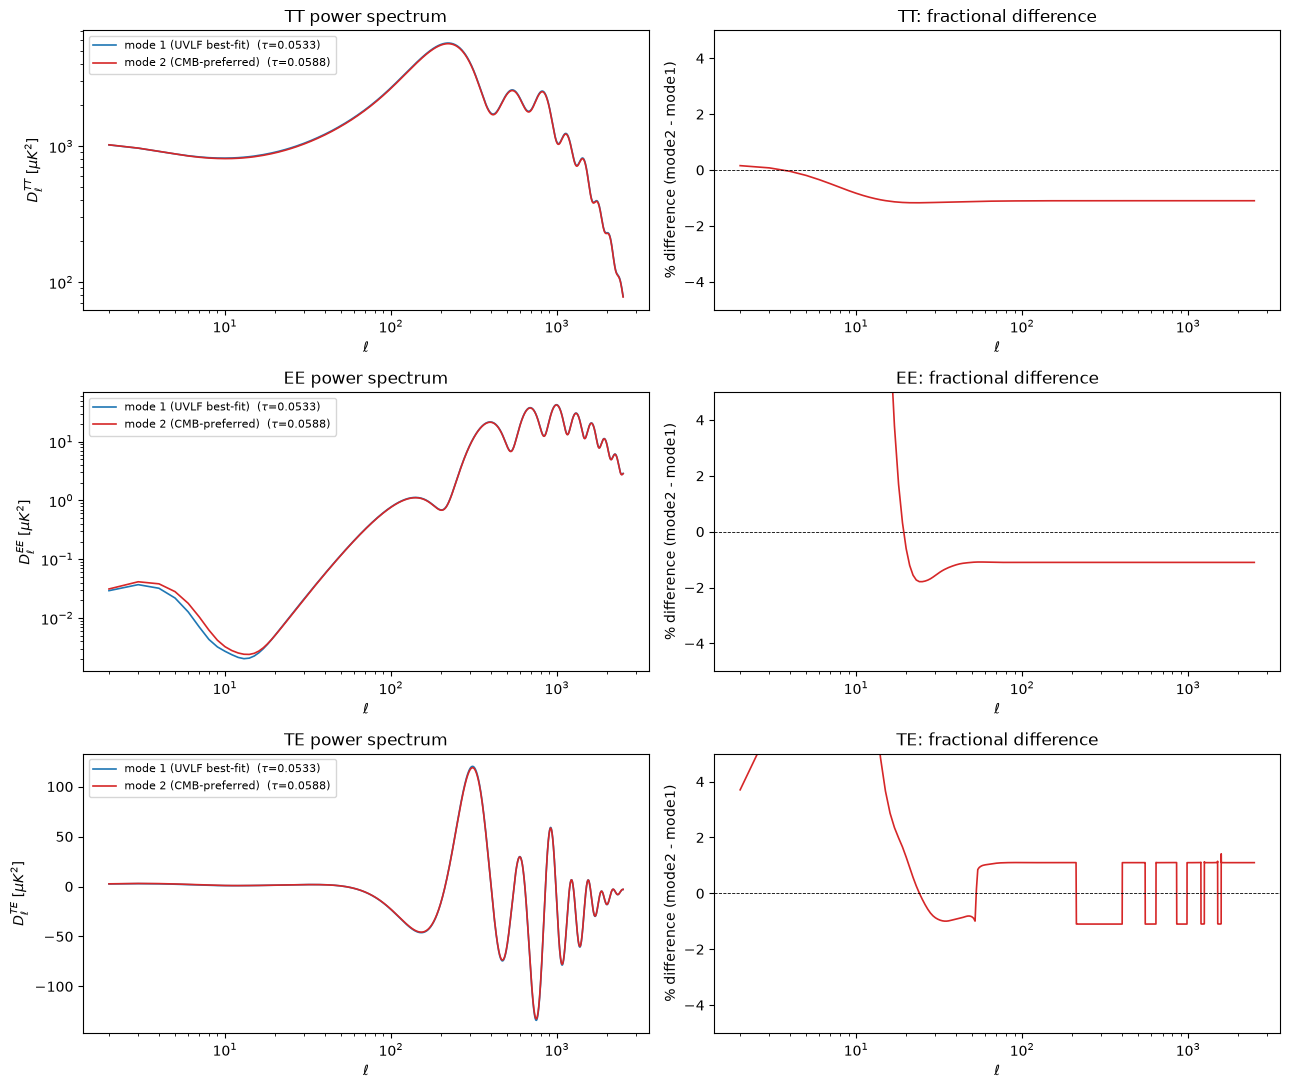

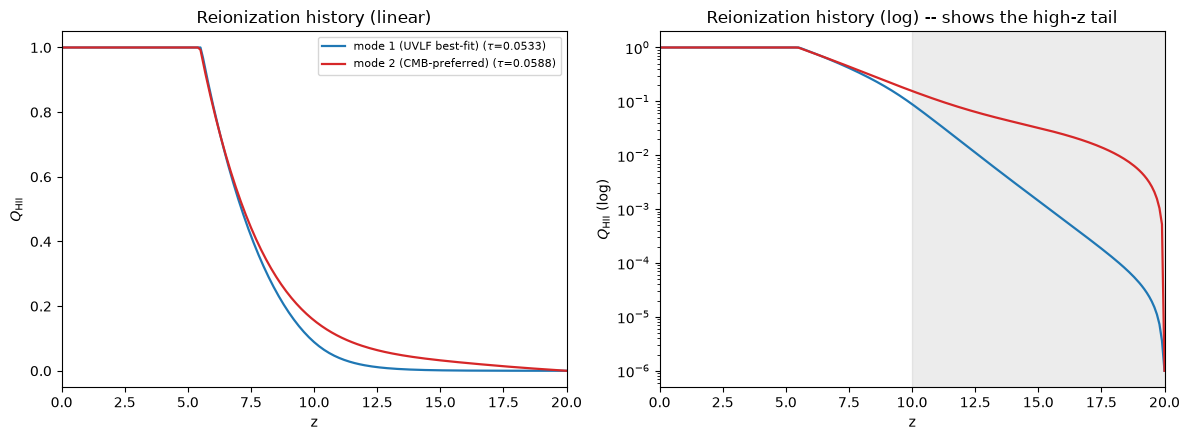

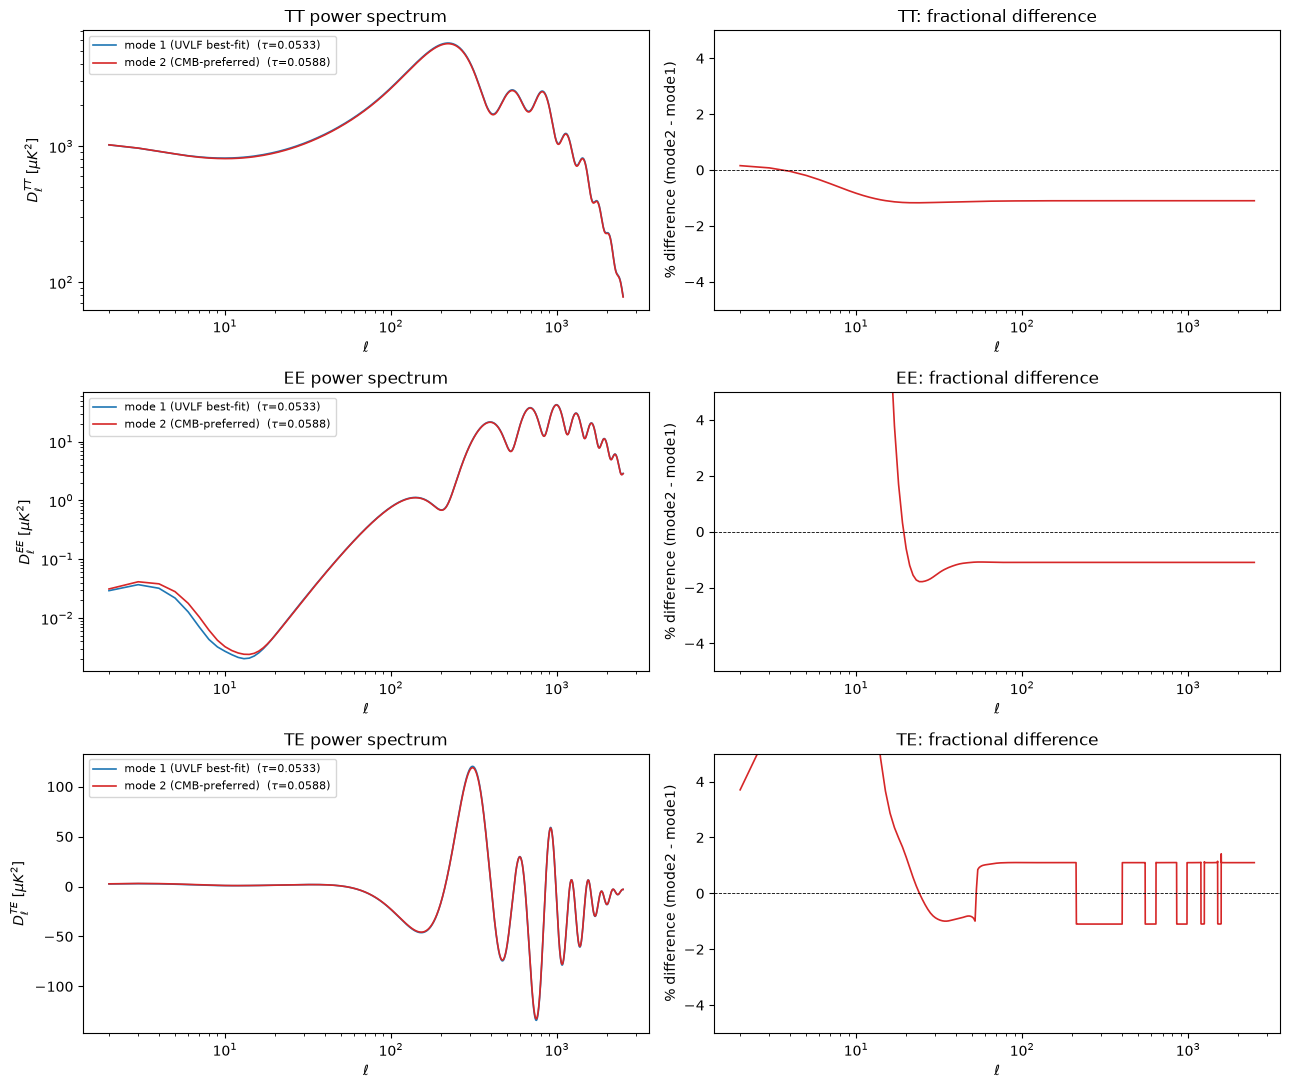

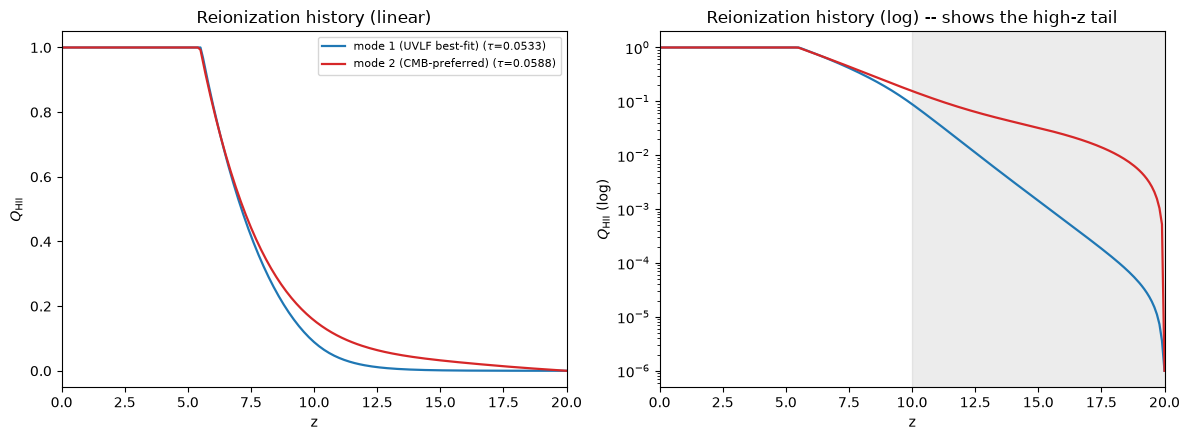

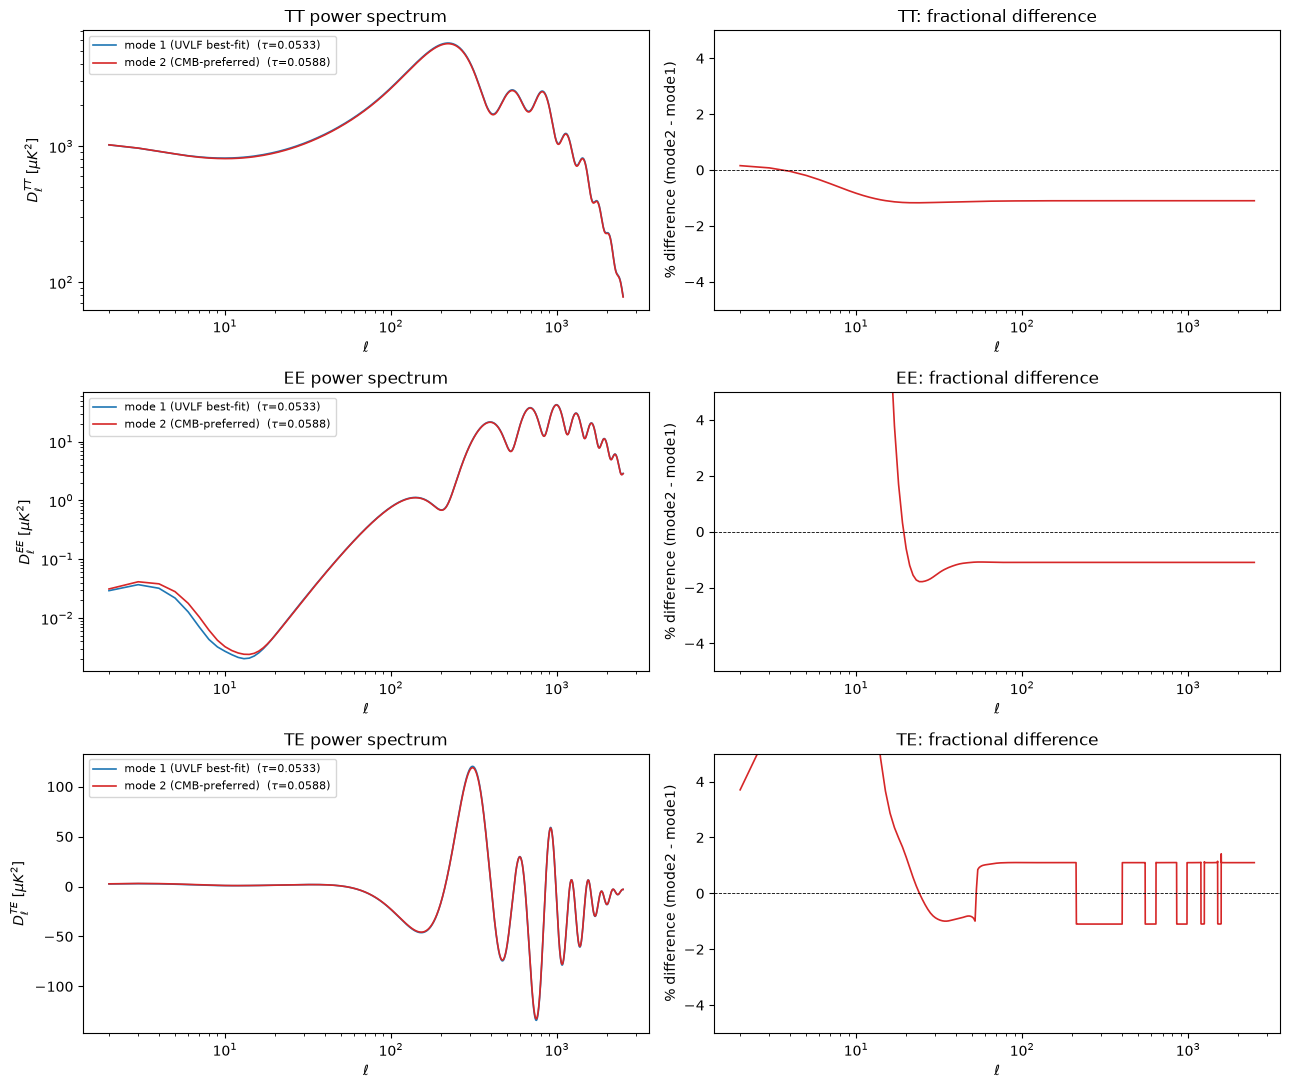

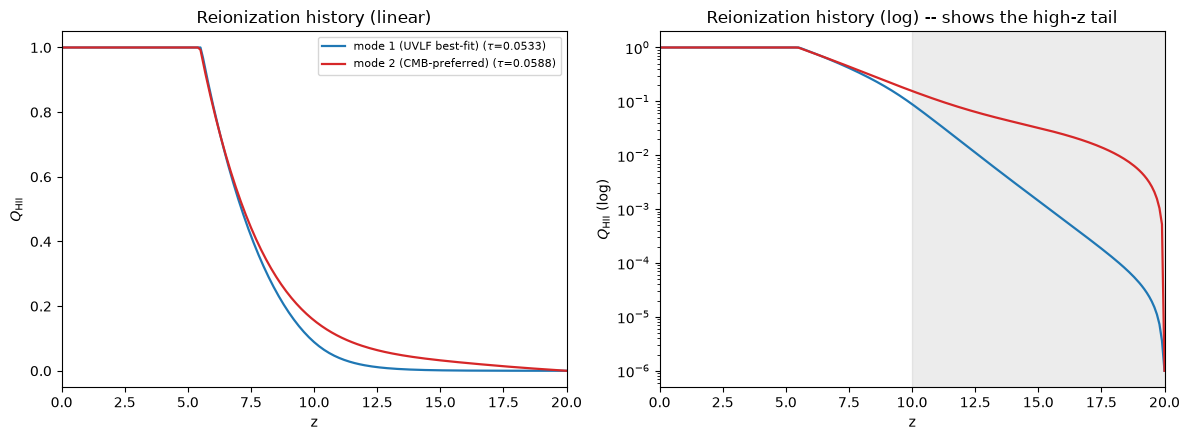

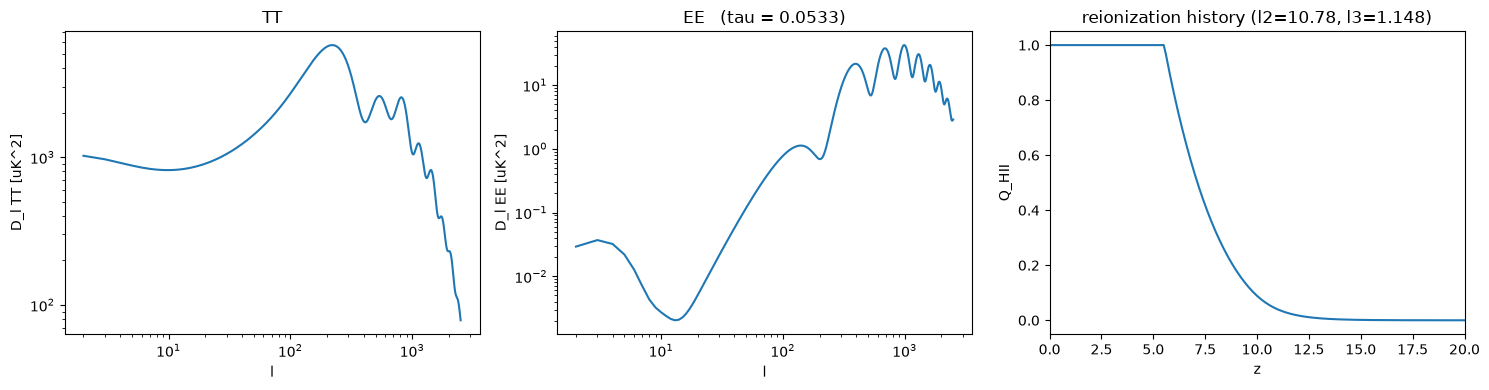

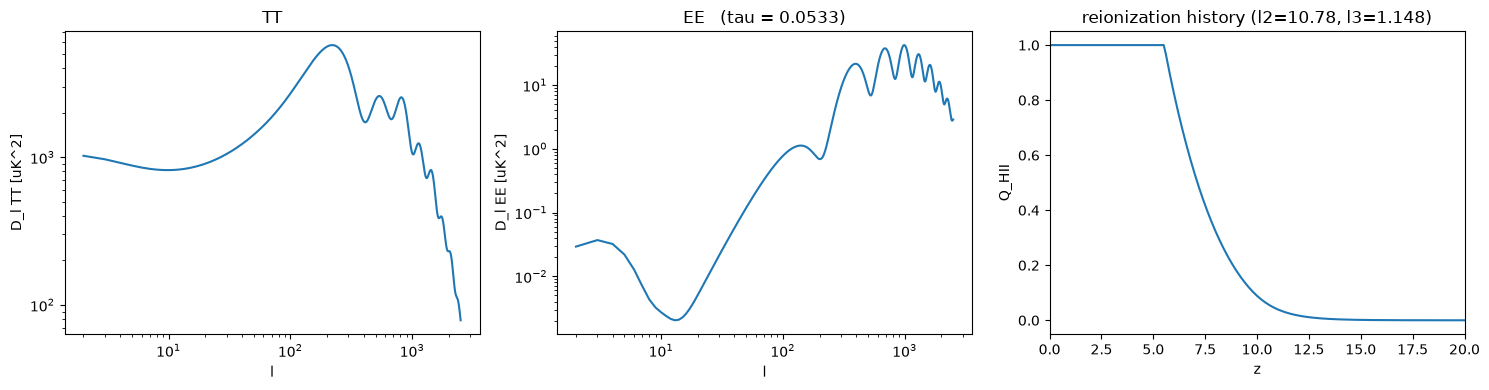

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys

%matplotlib inline

PROJECT = "/home/aayush/PROJECT_NCRA"
os.chdir(PROJECT + "/data_files")
sys.path.insert(0, PROJECT)
import reion_uvlf_4params as uvlf
from classy import Class

#data
lsum, ldiff, l2, l3 = -0.458, -0.883, 10.78, 1.148
H0, omega_b, omega_cdm, n_s, A_s = 67.4, 0.0224, 0.120, 0.965, 2.097e-9


h = H0 / 100.0
omega_m = (omega_cdm + omega_b) / h**2
omega_l = 1.0 - omega_m
omega_b_frac = omega_b / h**2

c = Class()
c.set({"output": "mPk", "P_k_max_1/Mpc": 500., "z_max_pk": 1.,"H0": H0, "omega_b": omega_b, "omega_cdm": omega_cdm,
       "n_s": n_s, "A_s": A_s})

c.compute()
kk = np.logspace(-4, np.log10(500), 2000)
Pk0 = np.array([c.pk_lin(k, 0.0) for k in kk])
lnk = np.log(kk / h)
lnpk = np.log(Pk0 * h**3)
c.struct_cleanup()

logl, d = uvlf.log_likelihood(lsum, ldiff, l2, l3, lnk, lnpk, omega_m, omega_l, h, omega_b_frac, YHe=0.24)
z = np.asarray(d["z_arr"])
Q = np.asarray(d["QHII_arr"])
print("chi2_uvlf =", -2 * logl)
print("tau_e     =", d["tau_e"])

order = np.argsort(z)
z, Q = z[order], Q[order]
xe = np.where(z >= 3.0, Q * 1.0789, Q * 1.1578)
xe = np.where(xe < 1e-4, 0.0, xe)
last = np.where(xe > 0)[0][-1]
z_inj = np.append(z[:last+1], z[last+1] if last+1 < len(z) else z[-1] + 0.2)
xe_inj = np.append(xe[:last+1], 0.0)

cc = Class()
cc.set({"output": "tCl,pCl,lCl", "lensing": "yes", "N_ur": 3.044,
        "H0": H0, "omega_b": omega_b, "omega_cdm": omega_cdm,
        "n_s": n_s, "A_s": A_s,
        "reio_parametrization": "reio_inter",
        "reio_inter_num": int(len(z_inj)),
        "reio_inter_z": ",".join(f"{v:g}" for v in z_inj),
        "reio_inter_xe": ",".join(f"{v:.6f}" for v in xe_inj)})
cc.compute()
cls = cc.lensed_cl(2500)
tau = cc.get_current_derived_parameters(['tau_reio'])['tau_reio']
cc.struct_cleanup()
print("tau_class =", tau)

ell = np.arange(2501)
fac = ell * (ell + 1) / (2 * np.pi) * (2.7255e6)**2

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].loglog(ell[2:], fac[2:] * cls['tt'][2:])
ax[0].set_xlabel("l")
ax[0].set_ylabel("D_l TT [uK^2]")
ax[0].set_title("TT")

ax[1].loglog(ell[2:], fac[2:] * cls['ee'][2:])
ax[1].set_xlabel("l")
ax[1].set_ylabel("D_l EE [uK^2]")
ax[1].set_title(f"EE   (tau = {tau:.4f})")

ax[2].plot(z, Q)
ax[2].set_xlim(0, 20)
ax[2].set_xlabel("z")
ax[2].set_ylabel("Q_HII")
ax[2].set_title(f"reionization history (l2={l2}, l3={l3})")

plt.tight_layout()
plt.show()